In [ ]:
# Hospital Readmission Risk Analysis — Exploratory Data Analysis

**Dataset:** UCI Diabetes 130-US Hospitals (1999–2008)  
**Source:** https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008  
**Author:** Bala Dasari  

## Business Context

Under the U.S. CMS Hospital Readmissions Reduction Program (HRRP), 
hospitals lose up to 3% of Medicare reimbursement for excess 30-day readmissions — typically $1–3M per hospital annually. 
Diabetic patients have higher readmission rates than the general population.

This notebook performs the data preparation and exploratory analysis that powers the multi-page Power BI dashboard in this repository.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [9]:
df.shape
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      99493 non-null   object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    3197 non-null    object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                61510 non-null   object
 11  medical_specialty         51817 non-null   object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [13]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [15]:
df.dtypes

encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepiride         

In [19]:
df.duplicated().sum()

0

In [21]:
# Same patient, multiple encounters 
df['patient_nbr'].nunique()

71518

In [23]:
#Patients with multiple visits
df['patient_nbr'].value_counts().head(10)

patient_nbr
88785891    40
43140906    28
1660293     23
88227540    23
23199021    23
23643405    22
84428613    22
92709351    21
88789707    20
29903877    20
Name: count, dtype: int64

In [25]:
#Null values
df.isnull().sum().sort_values(ascending=False).head(10)

weight               98569
max_glu_serum        96420
A1Cresult            84748
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
encounter_id             0
dtype: int64

In [27]:
#null Percentage
(df.isnull().sum() / len(df) * 100).round(2).sort_values(ascending=False).head(10)

weight               96.86
max_glu_serum        94.75
A1Cresult            83.28
medical_specialty    49.08
payer_code           39.56
race                  2.23
diag_3                1.40
diag_2                0.35
diag_1                0.02
encounter_id          0.00
dtype: float64

In [29]:
#Target Variable
df['readmitted'].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

In [31]:
df['readmitted'].value_counts(normalize=True).round(4) * 100

readmitted
NO     53.91
>30    34.93
<30    11.16
Name: proportion, dtype: float64

In [33]:
#Discharge disposition (to find hospice/deceased codes)
df['discharge_disposition_id'].value_counts()


discharge_disposition_id
1     60234
3     13954
6     12902
18     3691
2      2128
22     1993
11     1642
5      1184
25      989
4       815
7       623
23      412
13      399
14      372
28      139
8       108
15       63
24       48
9        21
17       14
16       11
19        8
10        6
27        5
12        3
20        2
Name: count, dtype: int64

In [35]:
df = df[~df['discharge_disposition_id'].isin([11, 13, 14, 19, 20, 21])]
df.shape

(99343, 50)

In [37]:
#drop weight mcolumn
df = df.drop('weight', axis=1)
df.shape

(99343, 49)

In [39]:
#Recheck readmission rate after cleaning 
df['readmitted'].value_counts(normalize=True).round(4) * 100

readmitted
NO     52.87
>30    35.74
<30    11.39
Name: proportion, dtype: float64

In [41]:
#Age Group 
def age_group(a):
    if a in ['[0-10)', '[10-20)', '[20-30)', '[30-40)']:
        return 'Young'
    elif a in ['[40-50)', '[50-60)', '[60-70)']:
        return 'Middle'
    return 'Senior'

df['age_group'] = df['age'].apply(age_group)
df['age_group'].value_counts()

age_group
Middle    48726
Senior    44354
Young      6263
Name: count, dtype: int64

In [43]:
#Visit group
df['total_visits'] = df['number_inpatient'] + df['number_emergency'] + df['number_outpatient']

def visit_group(v):
    if v == 0: return '0 Visits'
    elif v <= 2: return '1-2 Visits'
    elif v <= 5: return '3-5 Visits'
    return '6+ Visits'

df['visit_group'] = df['total_visits'].apply(visit_group)
df['visit_group'].value_counts()

visit_group
0 Visits      54676
1-2 Visits    29207
3-5 Visits    11136
6+ Visits      4324
Name: count, dtype: int64

In [45]:
#Diagnosis Category
def diag_cat(c):
    if pd.isna(c): return 'Unknown'
    c = str(c)
    if c.startswith('V'): return 'Other'
    if c.startswith('E'): return 'Injury'
    if c.startswith('250'): return 'Diabetes'
    try:
        n = float(c)
    except:
        return 'Other'
    if 390 <= n <= 459 or n == 785: return 'Circulatory'
    if 460 <= n <= 519 or n == 786: return 'Respiratory'
    if 520 <= n <= 579 or n == 787: return 'Digestive'
    if 800 <= n <= 999: return 'Injury'
    if 710 <= n <= 739: return 'Musculoskeletal'
    if 580 <= n <= 629 or n == 788: return 'Genitourinary'
    if 140 <= n <= 239: return 'Neoplasms'
    return 'Other'

df['diagnosis_category'] = df['diag_1'].apply(diag_cat)
df['diagnosis_category'].value_counts()

diagnosis_category
Circulatory        29681
Other              17792
Respiratory        13934
Digestive           9333
Diabetes            8661
Injury              6854
Genitourinary       5002
Musculoskeletal     4935
Neoplasms           3131
Unknown               20
Name: count, dtype: int64

In [47]:
#Readmission by visit group
df.groupby('visit_group').apply(lambda x: (x['readmitted'] == '<30').mean() * 100).round(2)

visit_group
0 Visits       8.32
1-2 Visits    12.87
3-5 Visits    16.86
6+ Visits     26.04
dtype: float64

In [49]:
#Heatmap data: age × visits
df.groupby(['age_group', 'visit_group']).apply(lambda x: (x['readmitted'] == '<30').mean() * 100).round(2).unstack()

visit_group,0 Visits,1-2 Visits,3-5 Visits,6+ Visits
age_group,,,,
Middle,7.44,12.05,16.78,26.21
Senior,9.80,13.60,16.69,22.66
Young,5.26,13.69,18.78,34.84


In [51]:
#Readmission by diagnosis 
df.groupby('diagnosis_category').apply(lambda x: (x['readmitted'] == '<30').mean() * 100).round(2).sort_values(ascending=False)

diagnosis_category
Unknown            25.00
Diabetes           13.10
Injury             12.40
Circulatory        11.69
Other              11.69
Genitourinary      11.04
Neoplasms          10.89
Digestive          10.82
Respiratory        10.06
Musculoskeletal     9.54
dtype: float64

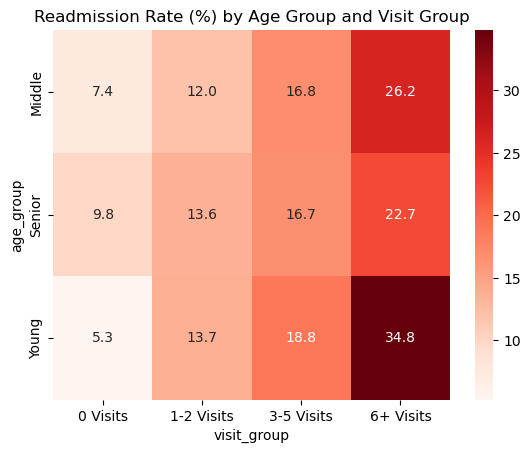

In [53]:
#Quick visualization of the heatmap insight
heatmap_data = df.groupby(['age_group', 'visit_group']).apply(lambda x: (x['readmitted'] == '<30').mean() * 100).unstack()
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='Reds')
plt.title('Readmission Rate (%) by Age Group and Visit Group')
plt.show()